In [1]:
import numpy as np
import matplotlib.pylab as plt
import pickle

In [2]:
filename = 'Block10_CGT.pkl'

with open(filename,'rb') as file:
    CGT01 = pickle.load(file)

In [3]:
#Bond length
b = 1

#Ree parameters
Nlpf = 10009
M = 100; N = 100
Ndata = int(M*N)
Ncols = 9

#Get End-to-end distance
def Ree(D):
    
    # ITEM: ATOMS id mol type xu yu zu vx vy vz
    Nf = D.shape[0]
    
    #Extract all atoms that are type 3
    Type3 = D[D[:,:,2] == 3]
    Type3 = Type3.reshape(Nf, 100, 9)

    #Extract all atoms that are type 4
    Type4 = D[D[:,:,2] == 4]
    Type4 = Type4.reshape(Nf, 100, 9)

    #Extract Position vector
    Type3 = Type3[1:,:,3:6] #Exclude first frame
    Type4 = Type4[1:,:,3:6]

    #Extract End-to-end vector
    dX = Type3-Type4
    Rhp = np.linalg.norm(dX, axis = 2)
    
    return Rhp

#Get segmental end-to-end distance
def segRee(D, Blck, Atom_Type):
    Nf = D.shape[0]
    Mseg = N//Blck*M
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,Blck,9) #exclude first frame

    Xseg = D[:,:,:,3:6]

    if(Atom_Type == 'Hydrophilic'):
        # Get just the odd segments (hydrophilic segments)
        Xhp =  Xseg[:,1::2,:,:]
    elif(Atom_Type == 'Hydrophobic'):
        # Get just the even segments (hydrophobic segments)
        Xhp =  Xseg[:,0::2,:,:]
    
    # End-to-End vectors of the segments
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    return Rhp

In [4]:
#Define bin size and domain of order parameter
bin = 100
domain = [1, 9]
rang = np.linspace(domain[0], domain[1], bin + 1)
xh = (rang[:-1]+rang[1:])/2

In [5]:
#List of forces
CGT01.f

array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 2.  , 2.25, 2.3 , 2.4 , 2.5 ,
       3.  , 5.  ])

/tmp/ipykernel_260882/1460858298.py:8: RuntimeWarning: divide by zero encountered in log
  F = -0.1*np.log(prob)+f*xh


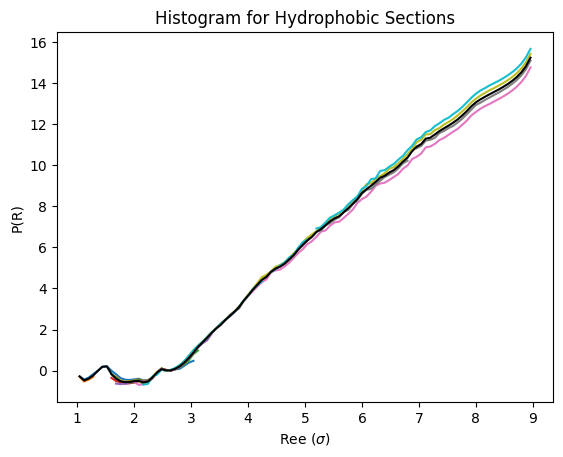

In [6]:
#Let's just use these simulations for now
Hphobic = np.empty((0,bin))

for i in range(1,11):
    f = CGT01.f[i]
    D = segRee(CGT01.ParsedRee[i], 10, 'Hydrophobic').flatten()
    prob = np.histogram(D,bins=rang)[0]
    F = -0.1*np.log(prob)+f*xh
    mask = (xh > 2.5) & (xh < 2.9)
    minimum = np.min(F[mask])
    plt.plot(xh, F-minimum)
    Hphobic = np.append(Hphobic, [F-minimum], axis = 0)

plt.xlabel("Ree ($\sigma$)")
plt.ylabel("P(R)")
plt.title('Histogram for Hydrophobic Sections')

#Take the mean
Hphobic = np.nan_to_num(Hphobic, posinf=np.nan, neginf=np.nan)
Hphobic = np.nanmean(Hphobic, axis = 0)
plt.plot(xh,Hphobic, color = 'black')

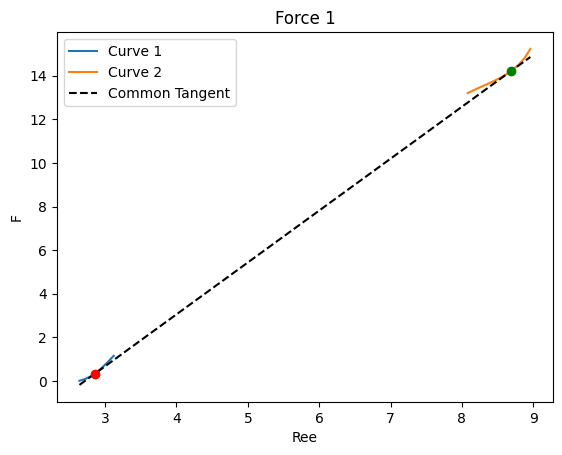

In [7]:
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize

mask1 = (2.6 < xh) & (xh < 3.2)
mask2 = (8 < xh) & (xh < 9)

# Input
x1 = xh[mask1]
y1 = Hphobic[mask1]

x2 = xh[mask2]
y2 = Hphobic[mask2]

# Fit splines to both curves
curve1 = CubicSpline(x1, y1)
curve2 = CubicSpline(x2, y2)

# Objective function: squared difference of tangents and point-to-line difference
def objective(p):
    t1, t2 = p  # candidate points on curve1 and curve2
    y1_val, y2_val = curve1(t1), curve2(t2)
    dy1, dy2 = curve1.derivative()(t1), curve2.derivative()(t2)

    # Minimize: difference in slopes and vertical distance between points along the common tangent
    slope_diff = dy1 - dy2
    y_line_at_t2 = y1_val + dy1 * (t2 - t1)
    y_diff = y_line_at_t2 - y2_val

    return slope_diff**2 + y_diff**2

# Initial guess (can be improved)
initial_guess = [x1[len(x1)//2], x2[len(x2)//2]]

# Minimize the objective function
result = minimize(objective, initial_guess, bounds=[(x1[0], x1[-1]), (x2[0], x2[-1])])
t1_opt, t2_opt = result.x

# Compute points and common tangent
pt1 = np.array([t1_opt, curve1(t1_opt)])
pt2 = np.array([t2_opt, curve2(t2_opt)])
slope = curve1.derivative()(t1_opt)

# Define tangent line function
def tangent_line(x):
    return pt1[1] + slope * (x - pt1[0])

# Plotting
x_vals = np.linspace(min(x1[0], x2[0]), max(x1[-1], x2[-1]), 500)
plt.plot(x1, y1, label='Curve 1')
plt.plot(x2, y2, label='Curve 2')
plt.plot(x_vals, tangent_line(x_vals), '--k', label='Common Tangent')
plt.plot(*pt1, 'ro')
plt.plot(*pt2, 'go')
plt.legend()
plt.xlabel('Ree')
plt.ylabel('F')
plt.title('Force 1')
plt.show()

In [8]:
def FJC(x):
    return 1 / np.tanh(x) - 1 / x

force1 = slope

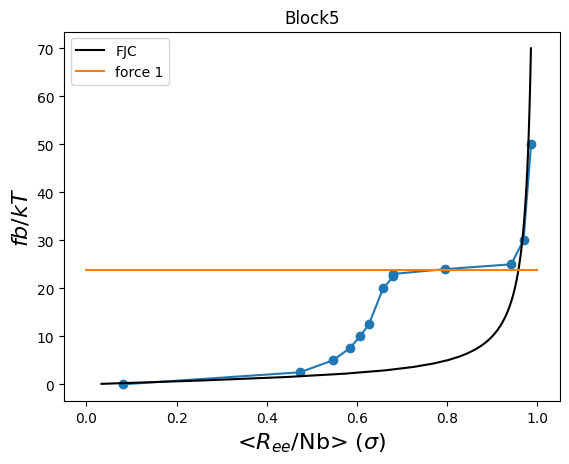

In [9]:
#Below Critical temperature
force = np.array(CGT01.f)
plt.plot(CGT01.aveRee / 99,force*b / 0.1, 'o-')

fbkt = np.linspace(0.1, 70, 100)

plt.plot(FJC(fbkt),fbkt, color = 'k', label = 'FJC')
plt.plot([0,1], [force1*b/0.1]*2, label='force 1')
plt.ylabel('$fb/kT$', fontsize=16)
plt.xlabel('<$R_{ee}$/Nb> ($\sigma$)', fontsize=16)
plt.title('Block5')
plt.legend()

## Plot average segmental Ree

In [18]:
#Adjust index of the force
fi = 1
ff = 11
#Forces that we're interested in
fT = (CGT01.f[fi:ff])/0.1

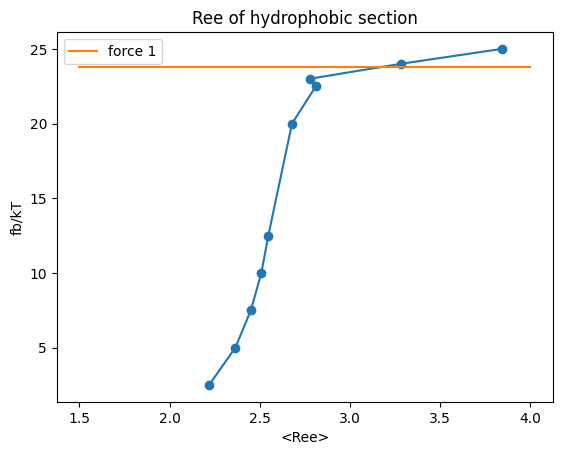

In [19]:
#Compare force to average Hydrophobic Ree
aveRee = np.empty(0)

for i in range(fi,ff):
    f = CGT01.f[i]
    D = segRee(CGT01.ParsedRee[i], 5, 'Hydrophobic').flatten()
    aveRee = np.append(aveRee, D.mean())

plt.plot(aveRee, fT,'o-')
plt.xlabel('<Ree>')
plt.ylabel('fb/kT')
plt.title('Ree of hydrophobic section')
plt.plot([1.5,4], [force1*b/0.1]*2, label = 'force 1')
plt.legend()

In [10]:
import numpy as np
from pymbar import MBAR

# Number of alchemical states (e.g., lambda = 0.0, 0.5, 1.0)
K = 3
# Number of samples per state
N_k = np.array([100, 100, 100])
N_total = np.sum(N_k)

# Simulate reduced potential energies u_k(x_n) across states
# u_kn has shape (K, N_total)
u_kn = np.zeros((K, N_total))

np.random.seed(0)
# Fill u_kn with synthetic data: assume state i has energy mean ~0.5*i
sample_idx = 0
for k in range(K):
    for n in range(N_k[k]):
        # Simulate the reduced potentials of this sample at all states
        u_kn[:, sample_idx] = [np.random.normal(loc=0.5*i + 0.1*k, scale=0.2) for i in range(K)]
        sample_idx += 1

# Initialize MBAR
mbar = MBAR(u_kn, N_k)

# Compute free energy differences and uncertainties
results = mbar.compute_free_energy_differences()
Delta_f = results['Delta_f']
dDelta_f = results['dDelta_f']
